# 8. Epi Gas

Part of the **[Fig. 6 chapter](fig6.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{outdir}npc.tsv'`  ·  _metadata_
- `f'{outdir}5kCG100k3C_summary.csv.gz'`  ·  _joint summary obj_
- `f'{indir}subtype_meta.tsv'`  ·  _metadata_
- `f'{outdir}L2/{ct}/5kCG_embed.h5ad'`  ·  _embedding h5ad_
- `f'{outdir}L2/{ct}/100k3C_embed.h5ad'`  ·  _embedding h5ad_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

[repro_guard] active — READ-ONLY (all writes skipped; inline figures still render)


In [2]:
from glob import glob

import anndata
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
from ALLCools.clustering import *
from ALLCools.integration.seurat_class import SeuratIntegration
from ALLCools.plot import *
from sklearn.metrics import pairwise_distances, roc_auc_score
from sklearn.preprocessing import normalize

# mpl.use('agg')
mpl.style.use("default")
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = "Helvetica"

import warnings
warnings.filterwarnings("ignore")


In [3]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [4]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{ENTEX_ROOT}/clustering/merged/'


In [5]:
npc = pd.read_csv(f'{outdir}npc.tsv', sep='\t', header=None, index_col=0, names=['npc_cg', 'npc_3c'])
meta = pd.read_csv(f'{outdir}5kCG100k3C_summary.csv.gz', index_col=0, header=0)


In [6]:
celltype_df = pd.read_csv(f'{indir}subtype_meta.tsv', sep='\t', header=0, index_col=0).fillna('')
# celltype_df['celltype_abbr'] = celltype_df['L1_annot'] + ' ' + celltype_df['celltype_abbr'].astype(str)
L2toct = celltype_df['celltype_L2_both_abbr']
meta['celltype_abbr'] = meta['subtype'].map(L2toct)


In [7]:
group_name = 'Epi-Gas'

In [8]:
ct = group_name
adata_mc = anndata.read_h5ad(f'{outdir}L2/{ct}/5kCG_embed.h5ad')
adata_3c = anndata.read_h5ad(f'{outdir}L2/{ct}/100k3C_embed.h5ad')
adata_3c = adata_3c[adata_mc.obs.index].copy()


In [9]:
npc_cg, npc_3c = npc.loc[ct].values

In [10]:
# adata_mc.obsm['X_lsi'] = normalize(adata_mc.obsm['5kCG_lsi'][:, :npc_cg], axis=1)
tsne(adata_mc, obsm='X_lsi', metric='euclidean', exaggeration=-1, perplexity=50, n_jobs=-1)
adata_mc.obsm[f'5kCG_u{npc_cg}_tsne'] = adata_mc.obsm['X_tsne'].copy()
dump_embedding(adata_mc, 'tsne')


AnnData object with n_obs × n_vars = 4601 × 0
    obs: 'FinalmCReads', 'mCHFrac', 'mCGFrac', 'CisLongContact', 'Cis/Trans', 'Donor', 'Tissue', 'celltype', 'ClusterTissue', 'tsne_0', 'tsne_1'
    obsm: '5kCG_lsi', '5kCG_u22_seuratL2', '5kCG_u22_seuratL2_tsne', 'X_lsi', 'X_tsne', '5kCG_u5_tsne'

In [11]:
meta.loc[adata_mc.obs.index, 'celltype_abbr'].value_counts()

celltype_abbr
Chief        2072
Foveolar     1287
Parietal      874
Neck          237
Endocrine     131
Name: count, dtype: int64

In [12]:
leg = pd.Index(['Foveolar', 'Neck', 'Chief', 'Parietal', 'Endocrine'])
color_palette = {xx:sns.color_palette('tab20')[i*2+1] for i,xx in enumerate(leg)}


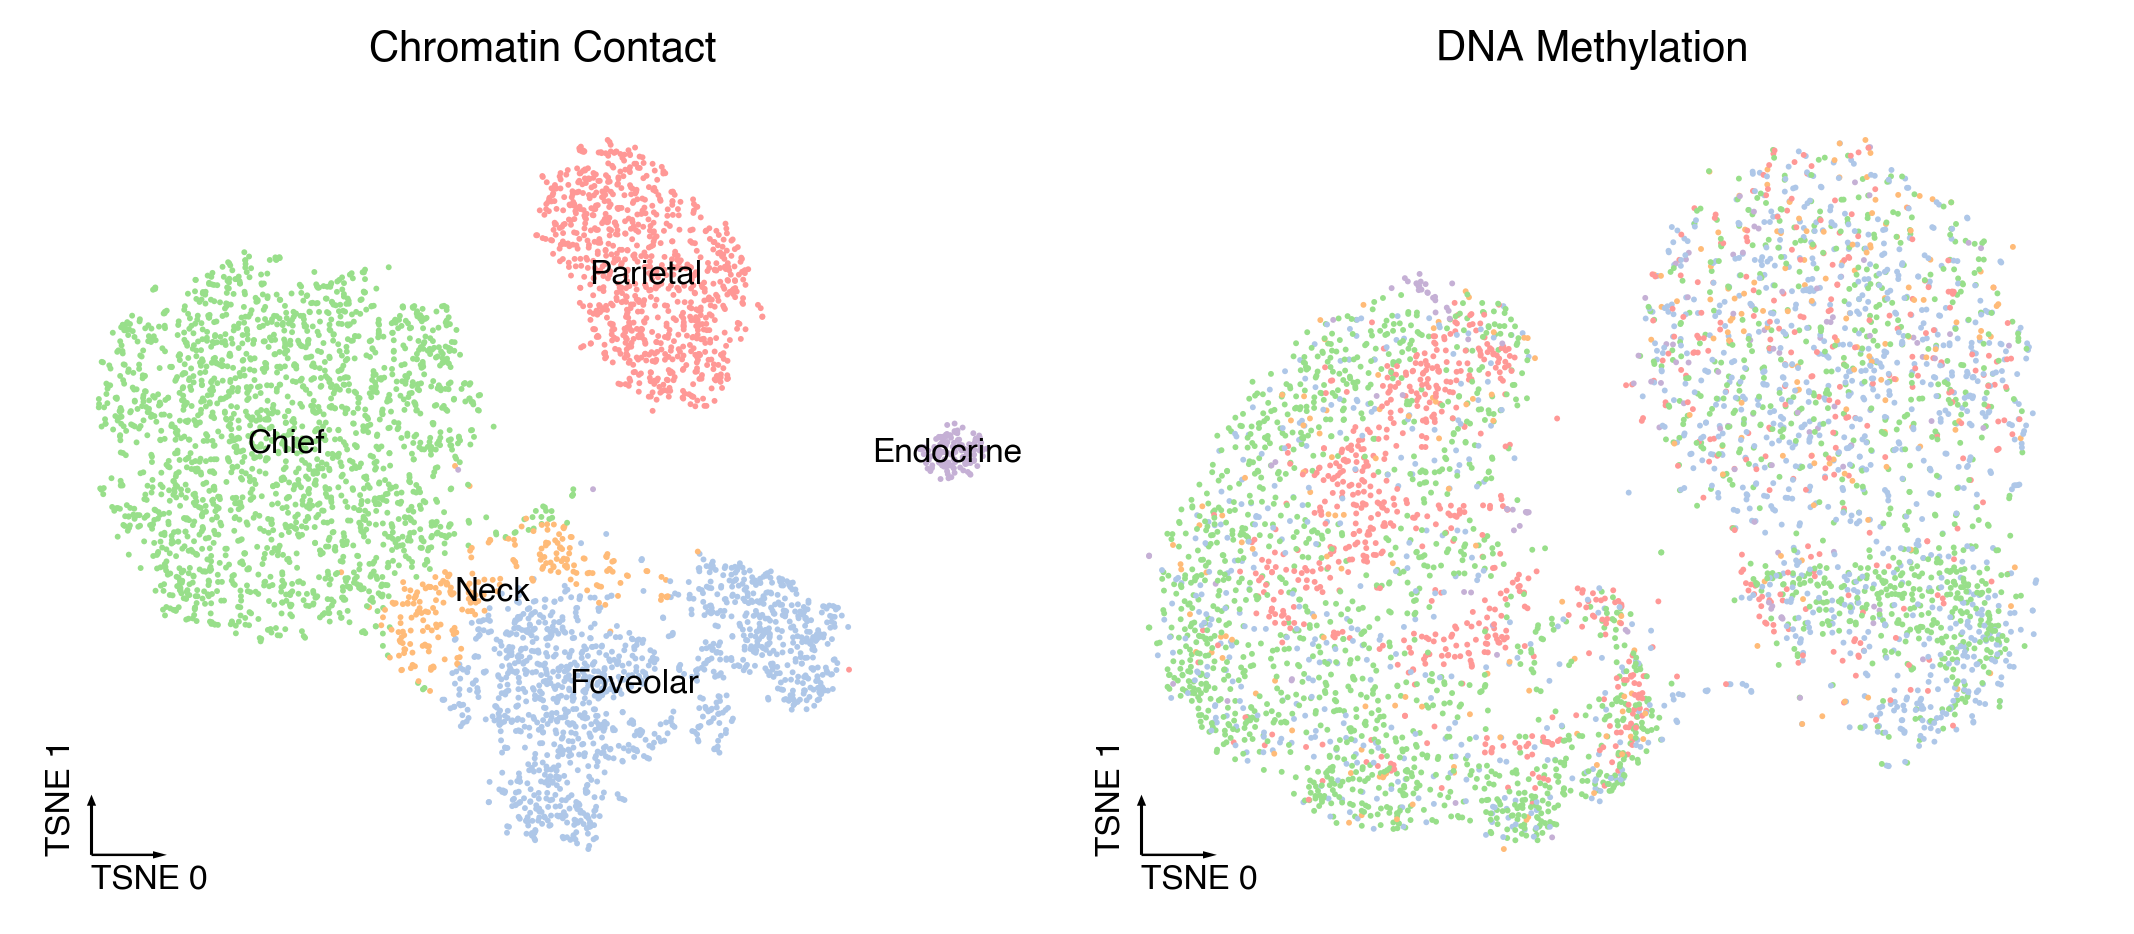

In [13]:
ds = 2
coord_base = 'tsne'

fig, axes = plt.subplots(1, 2, figsize=(7, 3), dpi=300, constrained_layout=True)
for i, adata in enumerate([adata_3c, adata_mc]):
    ax = axes[i]
    adata.obs['celltype_abbr'] = meta.loc[adata.obs.index, 'celltype_abbr']
    _ = categorical_scatter(data=adata.obs,
                            ax=ax,
                            coord_base=coord_base,
                            hue='celltype_abbr',
                            # text_anno='celltype_abbr', 
                            s=ds,
                            labelsize=8,
                            max_points=None,
                            palette=color_palette,
                            scatter_kws={'rasterized':True},
                            # legend_kws={'ncol':1}, 
                            # show_legend=True,
                           )
    
    if i==0:
        for yy in leg:
            x, y = np.mean(adata.obsm[f'X_{coord_base}'][adata.obs['celltype_abbr']==yy], axis=0)
            ax.text(x, y, yy, ha='center', va='center', fontsize=8)
        
    ax.set_title(['Chromatin Contact', 'DNA Methylation'][i], fontsize=10)
    
plt.savefig(f'{ct}/{ct}_modality_tsne.pdf', transparent=True)


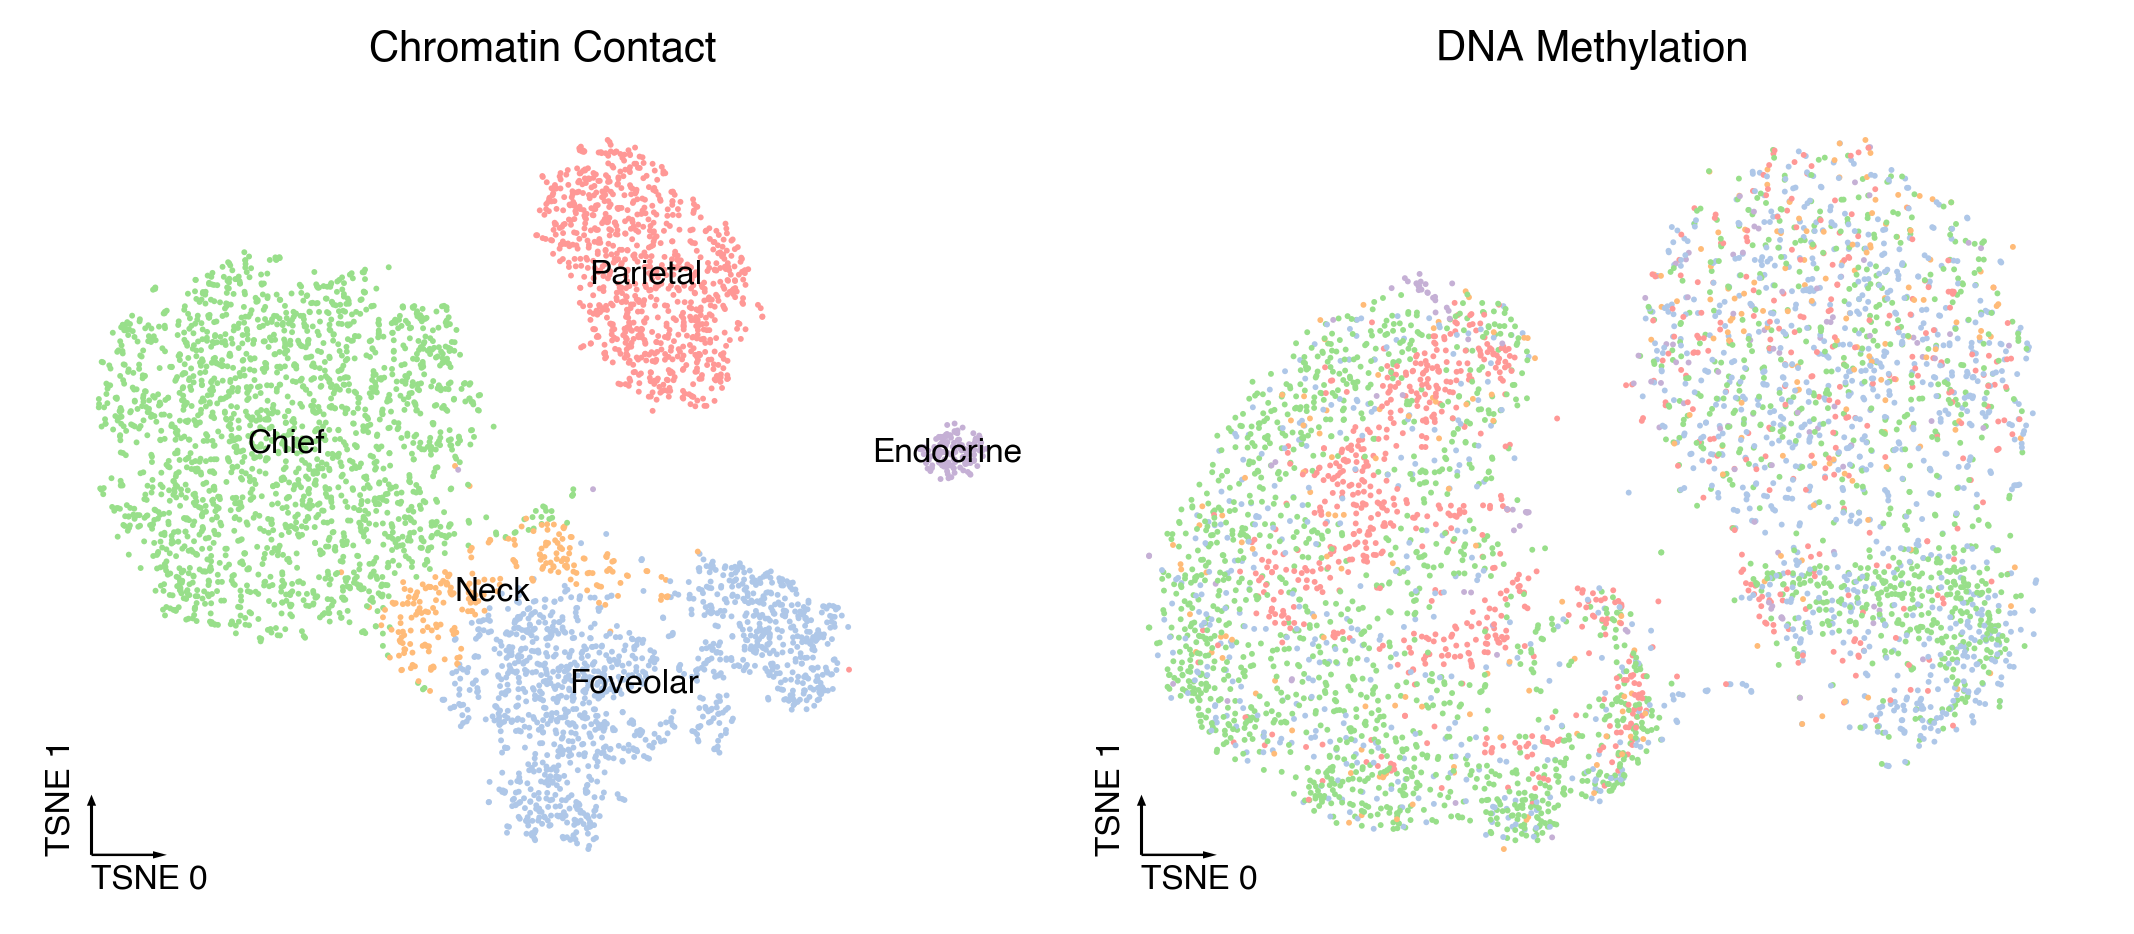

In [14]:
ds = 2
coord_base = 'tsne'

fig, axes = plt.subplots(1, 2, figsize=(7, 3), dpi=300, constrained_layout=True)
for i, adata in enumerate([adata_3c, adata_mc]):
    ax = axes[i]
    adata.obs['celltype_abbr'] = meta.loc[adata.obs.index, 'celltype_abbr']
    _ = categorical_scatter(data=adata.obs,
                            ax=ax,
                            coord_base=coord_base,
                            hue='celltype_abbr',
                            # text_anno='celltype_abbr', 
                            s=ds,
                            labelsize=8,
                            max_points=None,
                            palette=color_palette,
                            scatter_kws={'rasterized':True},
                            # legend_kws={'ncol':1}, 
                            # show_legend=True,
                           )
    
    if i==0:
        for yy in leg:
            x, y = np.mean(adata.obsm[f'X_{coord_base}'][adata.obs['celltype_abbr']==yy], axis=0)
            ax.text(x, y, yy, ha='center', va='center', fontsize=8)
        
    ax.set_title(['Chromatin Contact', 'DNA Methylation'][i], fontsize=10)
    
plt.savefig(f'{ct}/{ct}_modality_nobatch_tsne.pdf', transparent=True)
